# KDE density as a detectability proxy

Maybe this works better?

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

## Tests

### On uniform data

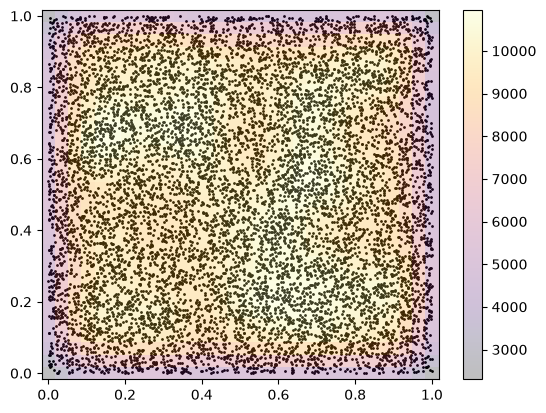

In [24]:
n_points = 10000
query_res = 30

# Generate data
rng = np.random.default_rng(seed=42)
data = rng.uniform(size=(n_points, 2))

# Perform kde
kde = gaussian_kde(data.T)
x_query = y_query = np.linspace(0, 1, num=query_res)
x, y = np.meshgrid(x_query, y_query)
query_data = np.vstack((x.flatten(), y.flatten()))
densities = n_points * kde(query_data).reshape(x.shape)

# Plot it!
plt.scatter(data[:, 0], data[:, 1], c="k", s=1)
colormap = plt.pcolormesh(x, y, densities, alpha=0.25, cmap="inferno")
_ = plt.colorbar(colormap)

### On uniform data with a different scale

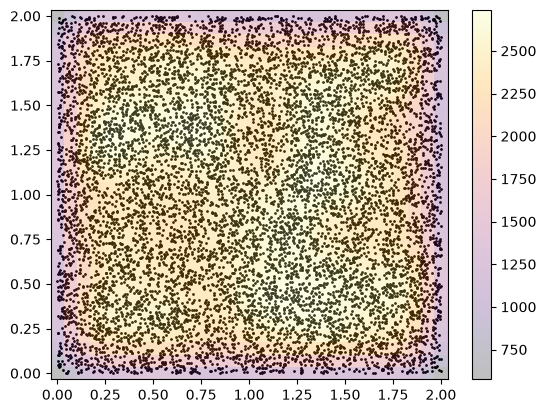

In [58]:
n_points = 10000
query_res = 30

# Generate data
rng = np.random.default_rng(seed=42)
data = rng.uniform(size=(n_points, 2), high=2)

# Perform kde
kde = gaussian_kde(data.T)
x_query = y_query = np.linspace(0, 2, num=query_res)
x, y = np.meshgrid(x_query, y_query)
query_data = np.vstack((x.flatten(), y.flatten()))
densities = n_points * kde(query_data).reshape(x.shape)

# Plot it!
plt.scatter(data[:, 0], data[:, 1], c="k", s=1)
colormap = plt.pcolormesh(x, y, densities, alpha=0.25, cmap="inferno")
_ = plt.colorbar(colormap)

### On split uniform data

Expected densities: 2000 18000


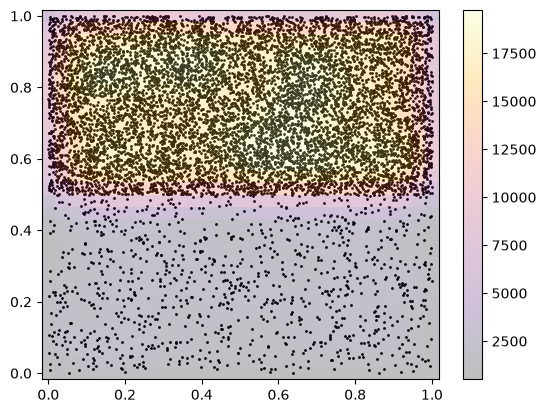

In [56]:
n_points = 10000
query_res = 30

# Generate data
rng = np.random.default_rng(seed=42)
points_first = n_points // 10
points_second = n_points - points_first

data_1 = rng.uniform(size=(points_first, 2))
data_2 = rng.uniform(size=(points_second, 2))
data_1[:, 1] = data_1[:, 1] / 2
data_2[:, 1] = data_2[:, 1] / 2 + 0.5
data = np.vstack((data_1, data_2))

print("Expected densities:", points_first * 2, points_second * 2)

# Perform kde
kde = gaussian_kde(data.T)
x_query = y_query = np.linspace(0, 1, num=query_res)
x, y = np.meshgrid(x_query, y_query)
query_data = np.vstack((x.flatten(), y.flatten()))
densities = n_points * kde(query_data).reshape(x.shape)

# Plot it!
plt.scatter(data[:, 0], data[:, 1], c="k", s=1)
colormap = plt.pcolormesh(x, y, densities, alpha=0.25, cmap="inferno")
_ = plt.colorbar(colormap)

wow, that actually works lol

### On Gaussian data

Expected densities: 416.625 833.375


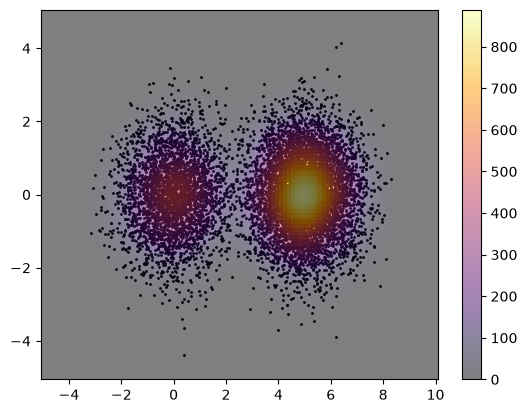

In [54]:
n_points = 10000
query_res = 100

# Generate data
rng = np.random.default_rng(seed=42)
points_first = n_points // 3
points_second = n_points - points_first

data_1 = rng.normal(size=(points_first, 2))
data_2 = rng.normal(loc=(5, 0), size=(points_second, 2))
data = np.vstack((data_1, data_2))

# Rough guess, since the points are roughly within ~2 sigma of the center
print("Expected densities:", points_first * 2 / 4**2, points_second * 2 / 4**2)

# Perform kde
kde = gaussian_kde(data.T)
x_query = np.linspace(-5, 10, num=query_res)
y_query = np.linspace(-5, 5, num=query_res)
x, y = np.meshgrid(x_query, y_query)
query_data = np.vstack((x.flatten(), y.flatten()))
densities = n_points * kde(query_data).reshape(x.shape)

# Plot it!
plt.scatter(data[:, 0], data[:, 1], c="k", s=1)
colormap = plt.pcolormesh(x, y, densities, cmap="inferno", alpha=0.5)
_ = plt.colorbar(colormap)